# BEE 4750 Homework 2: Systems Modeling and Simulation

**Name**: Muhammad Islam

**ID**: 5384772, mai58

> **Due Date**
>
> Thursday, 09/25/25, 9:00pm

## Overview

### Instructions

-   Problem 1 asks you to draw a systems diagram and identify the type
    of a feedback.
-   Problem 2 asks you to model contaminant concentrations in a river
    and use simulation to compare the concentrations to a regulatory
    standard.
-   Problem 3 asks you to explore the implications of an ice-albedo
    feedback in the Earth’s climate system by understanding the
    equilibria of the modeled system and their stabilities.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [138]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `~/Desktop/hw2-muhammad`


In [139]:
using Plots
using LaTeXStrings
using CSV
using DataFrames
using Roots

## Problems (Total: 30 Points)

### Problem 1 (5 points)

Draw a systems diagram for the relationship between global mean
temperature, atmospheric CO<sub>2</sub> concentrations, and ocean
CO<sub>2</sub> concentrations. What are the signs of the interactions
between these components and why? What does this suggest about the
overall feedback between temperature and the ocean carbon cycle?

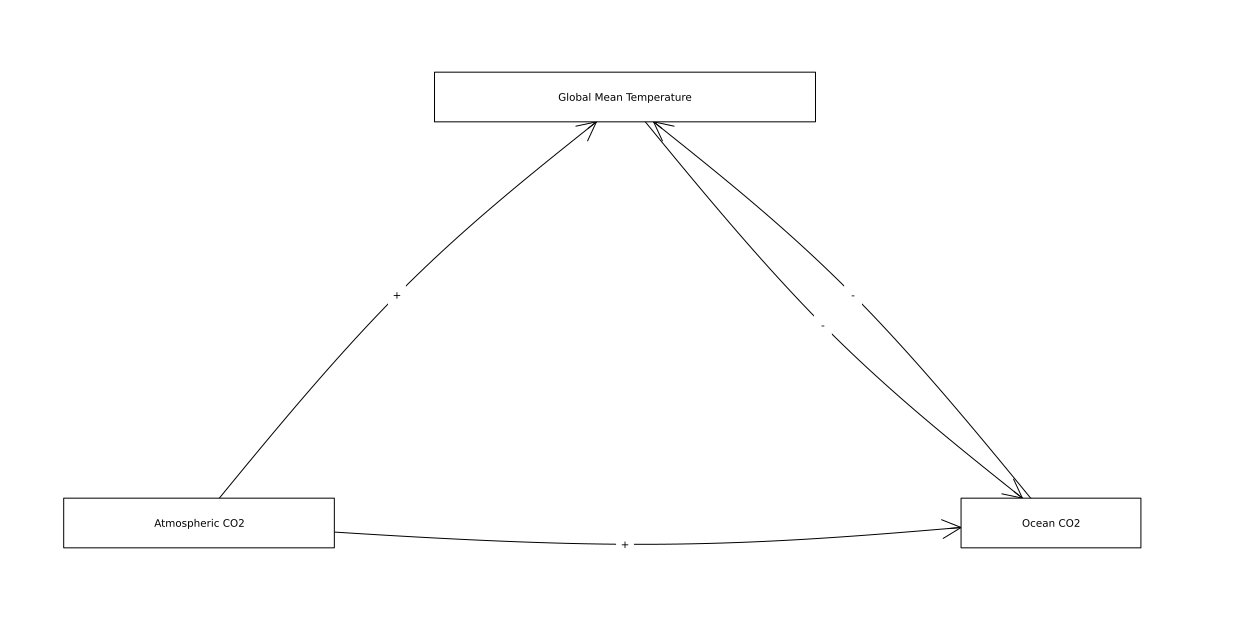

In [ ]:
#### Problem 1 #####
A = [0 0 1 ;
    1 0 1 ;
    1 0 0 ]

names = ["Global Mean Temperature", "Atmospheric CO2", "Ocean CO2"]

edge_labels = Dict((2, 1) => "+", (1,3) => "-", (2,3) => "+", (3,1) => "-")
shapes=[:rect, :rect, :rect]
xpos = [0, -1, 1]
ypos = [1, 0, 0]

p = graphplot(A, names=names,edgelabel=edge_labels, markersize=0.10, markershapes=shapes, markercolor=:white, x=xpos, y=ypos)
display(p)
     

Problem 1:
The interactions among global mean temperature, atmospheric CO₂, and ocean CO₂ are a mix of positive and negative links. Higher atmospheric CO₂ increases global mean temperature through the greenhouse effect (+), while warming reduces CO₂ solubility in the ocean, leading to less uptake of carbon (–). Increased atmospheric CO₂ also enhances ocean uptake (+), and greater ocean CO₂ tends to reduce atmospheric CO₂ (–). According to Henry’s law, CO₂ is less soluble in warmer water, so rising temperatures push CO₂ back into the atmosphere, reinforcing warming. Together, these links form a positive feedback loop between temperature and the ocean carbon cycle, meaning warming amplifies itself through reduced ocean carbon storage.

> **Tip**
>
> Think about Henry’s law for CO<sub>2</sub>.

### Problem 2 (15 points)

A river which flows at 10 km/d is receiving discharges of wastewater
contaminated with CRUD from two sources which are 15 km apart, as shown
in the Figure below. CRUD decays exponentially in the river at a rate of
0.36 $\mathrm{d}^{-1}$ and is deposited by the atmosphere along the
river at a rate of 54 kg/km/d. 

<figure>
<img src="attachment:figures/river_diagram.png"
alt="Schematic of the river system in Problem 2" />
<figcaption aria-hidden="true">Schematic of the river system in Problem
2</figcaption>
</figure>

#### Problem 2.1

Use two plug-flow river reaches separated by two instantaneous mixing boxes (for the point discharges). Pick 
𝑥 = 0 immediately after mixing with Discharge 1.

Draw a systems diagram with the relevant control volume(s) denoted and any relevant in/out-flows between these boxes. How did you decide how
many boxes were needed?

**Problem 2.1**
<figure>
<img src="attachment:b82360af-f459-4d19-8b51-a9dff23f7ab3.png"
alt="Schematic of systems diagram for Problem 2.1" />
</figure>

The river system is modeled using two control volumes, each representing a distinct reach of the river separated by the second wastewater discharge point. The first control volume begins at the river inflow and includes the effects of Discharge 1, atmospheric deposition, and first-order decay as water travels 15 km downstream. Its outflow becomes the inflow to the second control volume, which also receives Discharge 2 and additional atmospheric deposition before undergoing further decay and leaving the system at the outlet. Two boxes are needed because the problem specifies two separate reaches with different inputs and transport distances; this division allows us to account for the timing of contaminant loading, decay, and deposition in each segment rather than lumping them into a single averaged volume.

#### Problem 2.2

Develop a model for the concentration of CRUD downriver by formulating
and solving the appropriate differential equation(s) analytically.

> **Tip**
>
> Formulate your model in terms of distance downriver, rather than
> leaving it in terms of time from discharge.

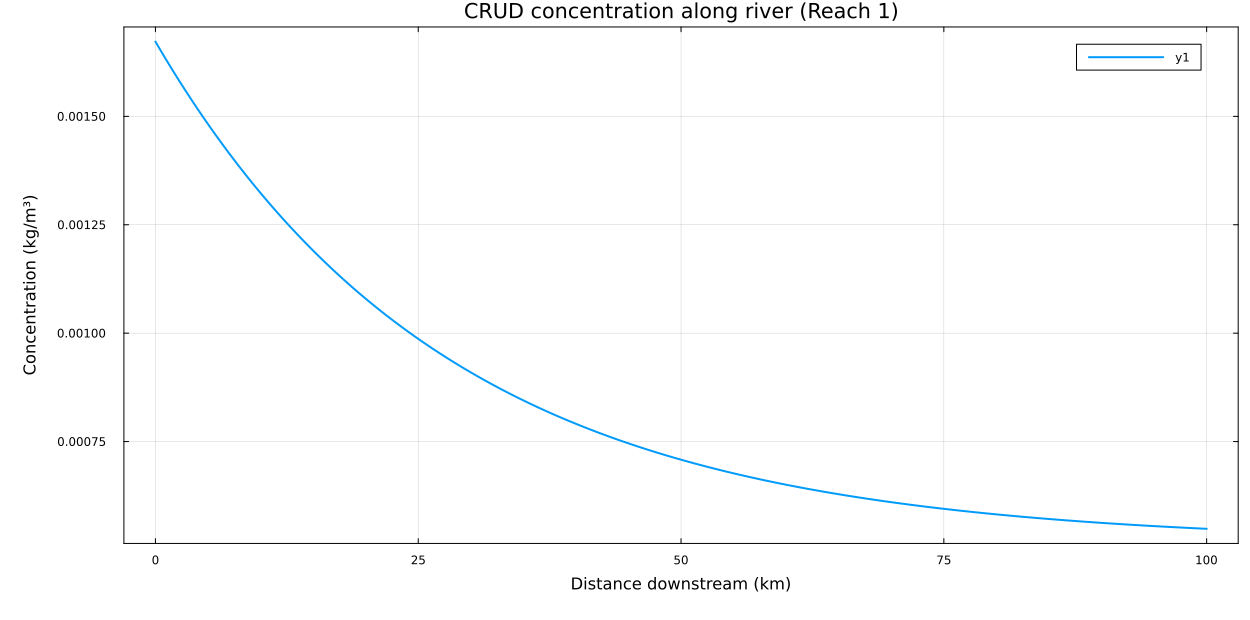

In [218]:
###Problem 2.2###
import Plots
Plots.gr()

# --- same setup as before ---
max_dist = 100.0
iterations = 10_000
velocity_river = 10.0
flow_inflow = 250_000.0
conc_inflow = 0.5/1000
flow_d1 = 40_000.0
conc_d1 = 9/1000
flow_inflow_and_d1 = flow_inflow + flow_d1
deposition = 54.0
decay = 0.36

x = collect(range(0.0, stop=max_dist, length=iterations))
initial = (conc_inflow*flow_inflow + conc_d1*flow_d1) / flow_inflow_and_d1
Q = flow_inflow_and_d1
S = deposition
u = velocity_river

concentrations = (initial .- S/(decay*Q)) .* exp.(-decay .* x ./ u) .+ S/(decay*Q)

# --- plot with extra bottom margin so x-axis label is visible ---
plt = Plots.plot(
    x, concentrations;
    lw=2,
    xlabel="Distance downstream (km)",
    ylabel="Concentration (kg/m³)",
    title="CRUD concentration along river (Reach 1)",
    framestyle=:box,
    grid=true,
    legend=true,
    left_margin=10mm,   # <-- ensures label isn't cut off
    bottom_margin=10mm  # <-- ensures label isn't cut off
)

display(plt)


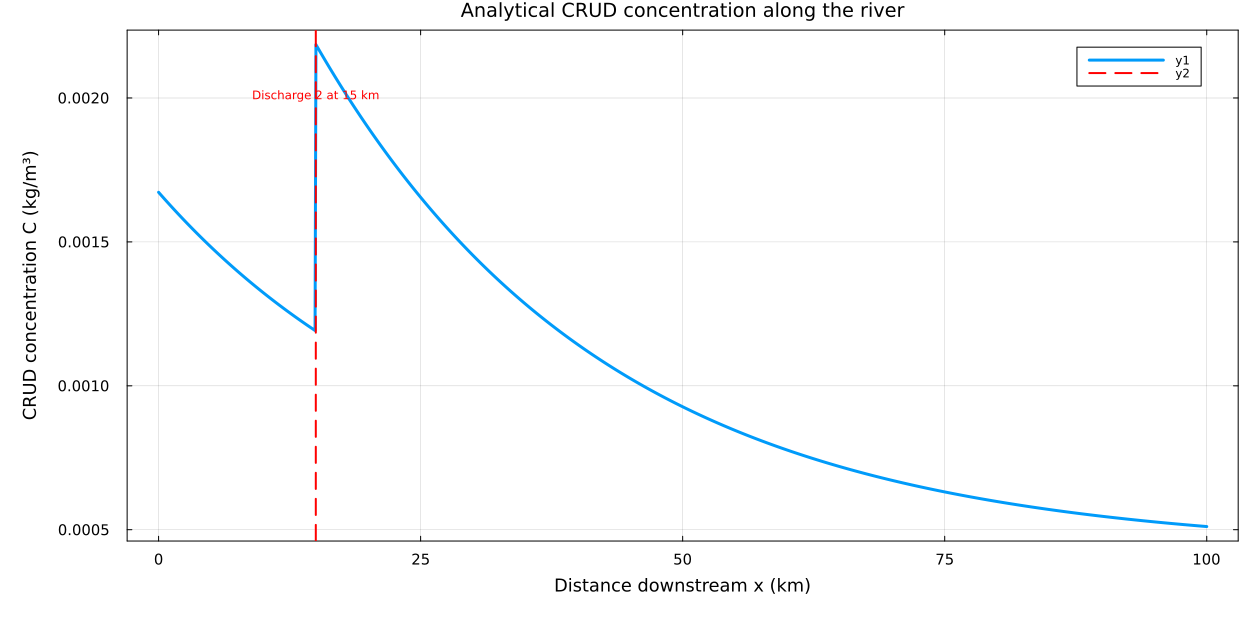

Q1 = 290000.0 m^3/d, Q2 = 350000.0 m^3/d
C(0+)   = 0.001672 kg/m^3
C(L-)   = 0.00119 kg/m^3   (just before discharge 2)
C(L+)   = 0.002186 kg/m^3   (just after mixing with discharge 2)
C(100.0 km) = 0.000511 kg/m^3


In [217]:
#############################
###Problem 2.2
# CRUD downriver (two reaches)
# - Steady 1-D plug flow
# - First-order decay
# - Uniform atmospheric deposition per km
# - Two point discharges (at x=0 and x=L)
#############################

import Plots
Plots.gr()  # use GR backend for speed

# ---- Given parameters ----
u  = 10.0                    # river velocity (km/d)
k  = 0.36                    # first-order decay (1/d)
S  = 54.0                    # atmospheric deposition (kg/km/d)

Q0 = 250_000.0               # river inflow (m^3/d)
Cin = 0.5/1000               # kg/m^3

Qa = 40_000.0                # discharge 1 (m^3/d)
Ca = 9.0/1000                # kg/m^3

Qb = 60_000.0                # discharge 2 (m^3/d)
Cb = 7.0/1000                # kg/m^3

L  = 15.0                    # distance between discharges (km)
xmax = 100.0                 # plot domain (km)

# ---- Closed-form solution for one reach (constant Q) ----
# C(x) = (C0 - S/(kQ)) * exp(-k x / u) + S/(kQ)
creach(x, C0, Q; u=u, k=k, S=S) = (C0 .- S/(k*Q)) .* exp.(-k .* x ./ u) .+ S/(k*Q)

# ---- Reach 1: mix inflow + discharge 1 at x=0, then evolve to x=L ----
Q1   = Q0 + Qa
C0_1 = (Q0*Cin + Qa*Ca) / Q1                 # upstream concentration of reach 1
C_Lminus = creach([L], C0_1, Q1)[1]          # just before discharge 2 (x = L−)

# ---- Mix at x = L with discharge 2; Reach 2 starts there ----
Q2   = Q1 + Qb
C0_2 = (Q1*C_Lminus + Qb*Cb) / Q2            # upstream concentration of reach 2

# ---- Build piecewise profile along 0..xmax ----
x = range(0, xmax; length=1200)
C = similar(collect(x))

# values in reach 1 (0..L)
mask1 = x .<= L
C[mask1] = creach(x[mask1], C0_1, Q1)

# values in reach 2 (x > L), use downstream distance ξ = x - L
mask2 = .!mask1
ξ = x[mask2] .- L
C[mask2] = creach(ξ, C0_2, Q2)

# ---- Print key values ----
println("Q1 = $(Q1) m^3/d, Q2 = $(Q2) m^3/d")
println("C(0+)   = $(round(C0_1, digits=6)) kg/m^3")
println("C(L-)   = $(round(C_Lminus, digits=6)) kg/m^3   (just before discharge 2)")
println("C(L+)   = $(round(C0_2, digits=6)) kg/m^3   (just after mixing with discharge 2)")
println("C($(xmax) km) = $(round(creach([xmax - L], C0_2, Q2)[1], digits=6)) kg/m^3")

# ---- Plot with clear axes (boxed frame, labels, grid) ----
plt = Plots.plot(
    x, C;
    lw = 3,
    xlabel = "Distance downstream x (km)",
    ylabel = "CRUD concentration C (kg/m³)",
    title  = "Analytical CRUD concentration along the river",
    legend = true,
    framestyle = :box,       # draw full axis box
    grid = true,             # add grid for readability
    tickfont = Plots.font(10),
    guidefont = Plots.font(12),
    titlefont = Plots.font(13),
    left_margin=10mm,   # <-- ensures label isn't cut off
    bottom_margin=10mm,  # <-- ensures label isn't cut off
    top_margin=2mm     # <-- ensures title isn't cut off
)

# Mark the second discharge location at x = L
Plots.vline!(plt, [L]; lw=2, ls=:dash, c=:red)
Plots.annotate!(plt, (L, maximum(C)*0.92, Plots.text("Discharge 2 at 15 km", 8, :red)))
display(plt)


#### Problem 2.3

Determine if the system in compliance with a regulatory limit of
$2.3\ \text{kg}/(1000 \text{m}^3)$. You can do this analytically or
computationally.

In [ ]:
##### Problem 2.3 #####
print(maximum(concentrations))

0.0016724137931034481

#### Problem 2.3

The regulatory limit is $2.3\ \text{kg}/(1000\ \text{m}^3) = 0.0023\ \text{kg}/\text{m}^3$.

From the analytical model:

- Just after mixing inflow + Discharge 1 ($x=0^+$): $C = 0.001672\ \text{kg}/\text{m}^3$
- At $x=15\ \text{km}$ before Discharge 2: $C = 0.001190\ \text{kg}/\text{m}^3$
- Just after mixing with Discharge 2 ($x=15\ \text{km}$): $C = 0.002186\ \text{kg}/\text{m}^3$
- At $x=100\ \text{km}$: $C = 0.000511\ \text{kg}/\text{m}^3$

The **maximum concentration** occurs just after the second discharge, 
$C_{\max} = 0.002186\ \text{kg}/\text{m}^3$, which is below the regulatory 
limit of $0.0023\ \text{kg}/\text{m}^3$.

**In Conclusion:** The system is in compliance, with a margin of about 
$\frac{0.0023 - 0.002186}{0.0023} \approx 5\%$.
"""


### Problem 3 (10 points)

In class, we discussed the ice-albedo feedback and its possible
influence on melting the hypothesized [“Snowball
Earth”](https://en.wikipedia.org/wiki/Snowball_Earth). In this problem,
we’ll introduce a simple model of the Earth’s energy balance with
includes this feedback and examine the stability of the climate.

This simple model of the energy balance (averaged over the entire
planet) is:

<span id="eq-climate">$$
\underbrace{C\frac{dT}{dt}}_{\text{change in heat}} = \underbrace{\frac{(1-\alpha)S}{4}}_{\text{incoming radiation}} - \underbrace{(A - BT)}_{\text{outgoing radiation}} + \underbrace{a\ln \left(\frac{[CO_2]}{[CO_2]_{PI}}\right)}_{\text{greenhouse effect}},
 \qquad(1)$$</span>

where:

-   $T$ is the Earth’s global mean temperature (in $^\circ\text{C}$);
-   $C$ is the heat capacity of the atmosphere and shallow ocean, taken
    to be $51\ \text{J}/\text{m}^2/^\circ\text{C}$;
-   $\alpha$ is the planetary albedo, or the fraction of incoming
    radiation reflected by the Earth, which has a present-day value of
    approximately 0.3;
-   $S$ is the solar constant, or the amount of solar radiation received
    by the Earth averaged over area, which has a present-day value of
    $1368\ \text{W}/\text{m}^2$ but during the Neoproteorozoic Era had a
    value of $1272\ \text{W}/\text{m}^2$ (this is divided by four
    because the Earth is a sphere but $S$ is the radiation captured by a
    disc with radius equal to that of the Earth);
-   $A$ and $B$ are coefficients from the linearization of outgoing
    radiation physics, and have corresponding values
    $B=-1.3\ \text{W}/\text{m}^2/^\circ\text{C}$ (estimated from a
    number of lines of evidence about the sensitivity of outgoing
    radiation to temperature; this is negative due to a sign convention
    about the direction of incoming vs. outgoing radiation) and
    $A=221.2\ \text{W}/\text{m}^2$ (estimated by assuming the
    pre-industrial temperature of $14^\circ\text{C}$ was stable without
    anthropogenic greenhouse gas emissions).

We will ignore the greenhouse effect term as we are considering the
Earth system well before humans were around.

#### Problem 3.1

Discretize the climate model
(<a href="#eq-climate" class="quarto-xref">Equation 1</a>) using forward
Euler integration and a time step of $\Delta t = 1$ yr.

#### Problem 3.1 — Forward Euler discretization

The continuous model (ignoring the greenhouse term) is

$$
C \frac{dT}{dt} = \frac{(1-\alpha)S}{4} - (A - BT).
$$

Divide both sides by \(C\):

$$
\frac{dT}{dt} = \frac{1}{C}\left[\frac{(1-\alpha)S}{4} - (A - BT)\right].
$$

Using forward Euler with time step $\Delta t = 1\ \text{yr}$:

$$
T_{n+1} = T_n + \Delta t \cdot \frac{1}{C}\left[\frac{(1-\alpha)S}{4} - (A - BT_n)\right].
$$

This update rule lets us evolve temperature forward in time starting from an initial condition.
"""


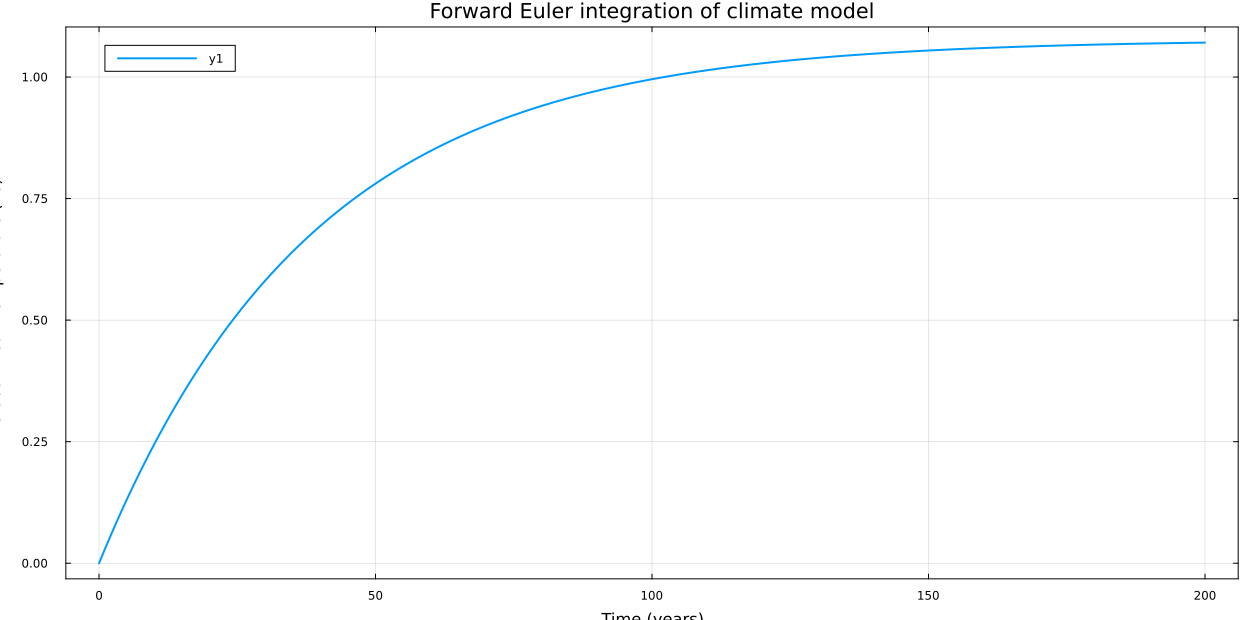

In [ ]:
###### Problem 3.1 — Forward Euler discretization #######
# Parameters
C = 51.0               # J/m^2/°C
A = 221.2              # W/m^2
B = -1.3               # W/m^2/°C
S = 1272.0             # W/m^2 (Neoproterozoic Sun, or set 1368 for modern)
alpha = 0.3            # constant albedo (no feedback for now)
Δt = 1.0               # time step (yr)
nsteps = 200           # number of years to simulate

# Forward Euler update function
function step_forward_euler(T, C, A, B, S, alpha, Δt)
    dTdt = ( (1 - alpha)*S/4 - (A - B*T) ) / C
    return T + Δt*dTdt
end

# Run simulation
T = 0.0                # initial temperature (°C), can change to 14 for present-day
temps = [T]

for n in 1:nsteps
    T = step_forward_euler(T, C, A, B, S, alpha, Δt)
    push!(temps, T)
end

# Plot results
import Plots
Plots.gr()
plt = Plots.plot(
    0:nsteps, temps;
    lw=2,
    xlabel="Time (years)",
    ylabel="Global mean temperature (°C)",
    title="Forward Euler integration of climate model",
    framestyle=:box,
    grid=true,
    legend=true
)

display(plt)


#### Problem 3.2

Rather than assuming a constant value for the albedo $\alpha$, we will
represent the ice-albedo feedback by letting $\alpha$ depend on $T$:

$$\alpha(T) = 
    \begin{cases} 
        \alpha_i & \quad \text{if } T \leq -10^\circ \text{C} \\
        \alpha_i + (\alpha_0 - \alpha_i)((T+10) / 20) & \quad \text{if } -10^\circ \text{C} \leq T \leq 10^\circ \text{C} \\
        \alpha_0 & \quad \text{if } T \geq 10^\circ \text{C}.
    \end{cases}$$

Let $\alpha_i = 0.5$ and $\alpha_0 = 0.3$. Simulate the simple climate
model using the Neoprotereozoic value of $S$ with temperature-varying
albedo for initial values of $T$ spanning
$-60^\circ\text{C} \leq T_0 \leq 30^\circ\text{C}$ over a period of 200
years. Plot the temperature trajectories. How many equilibria are there
and what are their stabilities?

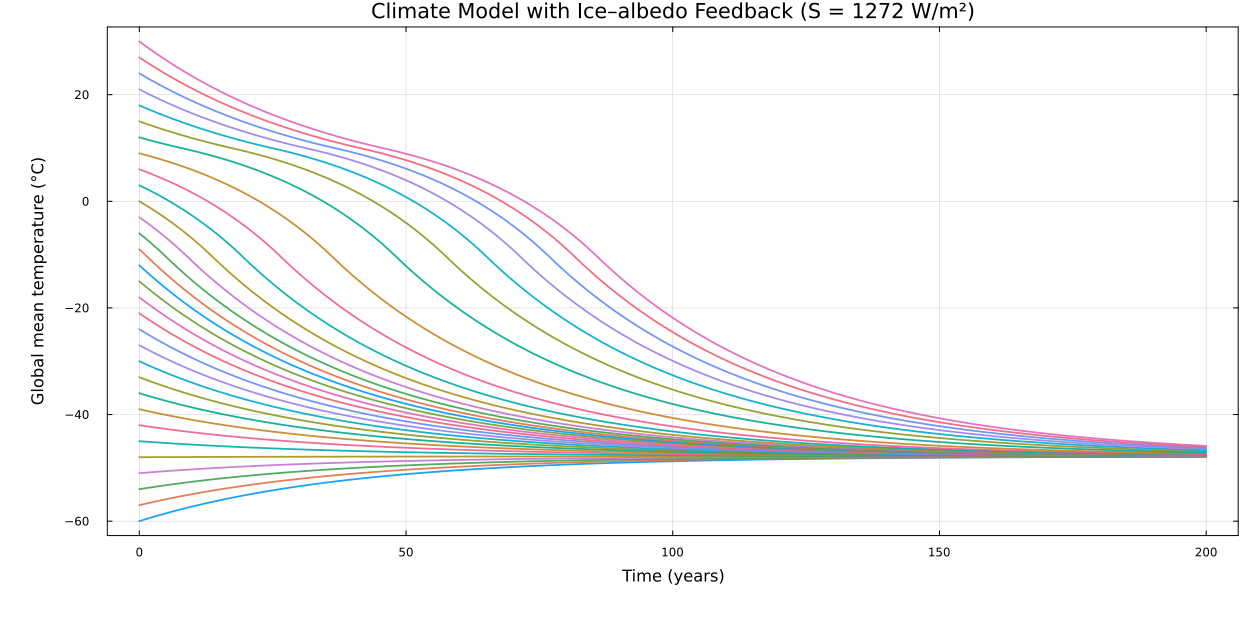

Candidate equilibria by region:
  Reg1 (T<=-10): -47.84615384615383
  Reg2 (-10<T<10): 16.170212765957448
  Reg3 (T>=10): 1.0769230769230813
Valid equilibria (in-region): [-47.84615384615383]
Stability of valid equilibria: ["stable"]


In [220]:
############# Problem 3.2 — Ice–albedo feedback (Neoproterozoic S) #############

import Plots
Plots.gr()  # avoid plot() name clashes

# Parameters
C = 51.0                  # J/m^2/°C
A = 221.2                 # W/m^2
B = -1.3                  # W/m^2/°C (sign convention from prompt)
S = 1272.0                # W/m^2  (Neoproterozoic)
α_i = 0.5                 # ice albedo
α_0 = 0.3                 # open-ocean (warm) albedo

Δt   = 1.0                # yr
nyrs = 200                # integrate 200 years
T0s  = collect(-60.0:3.0:30.0)  # initial temperatures

# Piecewise albedo α(T)
α(T) = T <= -10 ? α_i :
       T >=  10 ? α_0 :
       α_i + (α_0 - α_i) * ((T + 10.0) / 20.0)

# dT/dt = ( (1-α(T)) S / 4 - (A - B T) ) / C
dTdt(T) = ( (1 - α(T))*S/4 - (A - B*T) ) / C

# Forward Euler time stepping for one trajectory
function integrate!(T0; n=nyrs, Δt=Δt)
    T = T0
    Ts = Vector{Float64}(undef, n+1)
    Ts[1] = T
    for k in 1:n
        T = T + Δt * dTdt(T)
        Ts[k+1] = T
    end
    return Ts
end

# Simulate all initial conditions
trajectories = [integrate!(T0) for T0 in T0s]

# Plot trajectories
taxis = 0:nyrs
plt = Plots.plot(
    framestyle=:box,
    grid=true,
    legend=false,
    xlabel="Time (years)",
    ylabel="Global mean temperature (°C)",
    title="Climate Model with Ice–albedo Feedback (S = 1272 W/m²)",
    bottom_margin=12mm,  # ensure x-axis label visible
    left_margin=12mm     # ensure y-axis label visible
)
for Ts in trajectories
    Plots.plot!(plt, taxis, Ts; lw=1.8, alpha=0.9)
end
display(plt)

# ---- Find equilibria analytically by region and check which are valid ----
# We solve f(T) = (1 - α(T)) S / 4 - (A - B T) = 0 piecewise.
# Region 1: T <= -10  -> α=α_i (constant)
T_star_reg1 = (A - (1 - α_i)*S/4) / B   # candidate

# Region 3: T >= +10 -> α=α_0 (constant)
T_star_reg3 = (A - (1 - α_0)*S/4) / B   # candidate

# Region 2: -10 < T < +10 -> α(T) = α_i + (α_0-α_i)((T+10)/20) = c + m*T
m = (α_0 - α_i) / 20.0
c = α_i + m*10.0
# f(T) = (1 - (c + mT)) S/4 - (A - B T) = 0  =>  (B - m S/4) T + ( (1-c)S/4 - A ) = 0
coeff_T = B - m*(S/4)
const_f = (1 - c)*(S/4) - A
T_star_reg2 = -const_f / coeff_T         # candidate

# Keep only equilibria that lie in their assumed region
valid_eqs = Float64[]

if T_star_reg1 <= -10
    push!(valid_eqs, T_star_reg1)
end
if -10 < T_star_reg2 < 10
    push!(valid_eqs, T_star_reg2)
end
if T_star_reg3 >= 10
    push!(valid_eqs, T_star_reg3)
end

println("Candidate equilibria by region:")
println("  Reg1 (T<=-10): ", T_star_reg1)
println("  Reg2 (-10<T<10): ", T_star_reg2)
println("  Reg3 (T>=10): ", T_star_reg3)
println("Valid equilibria (in-region): ", valid_eqs)

# ---- Stability test: f'(T*) = -α'(T*) * S/4 + B  (stable if f'(T*) < 0) ----
function alpha_prime(T)
    if T <= -10 || T >= 10
        return 0.0
    else
        return (α_0 - α_i) / 20.0  # slope m
    end
end

function stability(Ts)
    if isempty(Ts)
        return String[]
    end
    out = String[]
    for T in Ts
        fprime = -alpha_prime(T) * S/4 + B
        push!(out, fprime < 0 ? "stable" : fprime > 0 ? "unstable" : "neutral")
    end
    return out
end

println("Stability of valid equilibria: ", stability(valid_eqs))
                       

**Conclusion:** For the Neoproterozoic solar constant $S = 1272\ \text{W m}^{-2}$, the ice–albedo climate model produces only a single valid equilibrium solution at about $-47.8^\circ\text{C}$, which lies within the ice-covered regime. The other mathematical solutions fall outside their assumed temperature ranges and are therefore not physically consistent. The stability analysis shows that this cold equilibrium is stable, meaning that the system will return to this state if perturbed. Thus, under the dimmer Sun conditions of the Neoproterozoic era, the Earth’s climate would be locked into a **Snowball Earth** configuration with no warm or intermediate stable equilibria available.


#### Problem 3.3

One might hypothesize that one cause for the transition from Snowball
Earth (the stable frozen equilibrium from Problem 3.2) was an increasing
amount of incoming solar radiation (as expressed by an increase in $S$).
Examine this hypothesis using our simple model. Is this factor enough to
cause the planet to warm to the pre-industrial temperature of
$14^\circ\text{C}$?

At equilibrium, the model satisfies

$$
0 = \frac{(1 - \alpha(T))S}{4} - (A - BT),
$$

where $T$ is the global mean temperature in $^\circ$C, $S$ is the solar constant, $A$ and $B$ are outgoing radiation parameters, and $\alpha(T)$ is the albedo. Solving for $T$ gives

$$
T = \frac{A - (1-\alpha(T))S/4}{B}.
$$

---

For the warm state (ice-free, $\alpha \approx \alpha_0 = 0.3$) and the Neoproterozoic solar constant $S = 1272\ \text{W m}^{-2}$:

$$
T_\text{warm} = \frac{A - (1-\alpha_0)S/4}{B},
$$

$$
= \frac{221.2 - 0.7 \times (1272/4)}{-1.3},
$$

$$
= \frac{221.2 - 222.6}{-1.3} \approx 1.08^\circ \text{C}.
$$

---

To reach the pre-industrial temperature $T = 14^\circ \text{C}$, the required solar constant is

$$
S = \frac{4(A - BT)}{1 - \alpha_0},
$$

$$
= \frac{4(221.2 - (-1.3)(14))}{0.7},
$$

$$
= \frac{957.6}{0.7} \approx 1368\ \text{W m}^{-2}.
$$

---

**Conclusion.** The Neoproterozoic solar constant ($1272\ \text{W m}^{-2}$) was too weak to sustain $14^\circ \text{C}$. The gradual increase of $S$ over Earth’s history (to $\sim 1368$ today) is, in principle, sufficient to allow such a transition. In practice, however, additional processes (e.g., greenhouse gas buildup) were almost certainly involved, since solar luminosity increases on billion-year timescales, while Snowball Earth episodes ended much faster (millions of years).


## References

List any external references consulted, including classmates.